In [2]:
#Célula 1: Configuração Global e Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

#Configurações visuais:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("\nSetup concluído.")


Setup concluído.


In [3]:
#Célula 2: Lendo a base geral e filtrando o Rio Grande do Norte (CO_ESTADO_GESTOR == 24)
df_bruto = pd.read_csv('tbEstabelecimento202601.csv', sep=';', low_memory=False, encoding='latin1')

print(f"Volume Bruto (Brasil): {df_bruto.shape[0]} linhas e {df_bruto.shape[1]} colunas.")

#Filtro do RN:
df_rn = df_bruto[df_bruto['CO_ESTADO_GESTOR'] == 24].copy()

#Seleção das 10 colunas:
colunas_selecionadas = [
    'TP_UNIDADE', 'CO_NATUREZA_JUR', 'TP_GESTAO', 'CO_TURNO_ATENDIMENTO',
    'TP_ESTAB_SEMPRE_ABERTO', 'CO_ATIVIDADE_PRINCIPAL', 'CO_CLIENTELA',
    'ST_CONEXAO_INTERNET', 'NU_LATITUDE', 'NU_LONGITUDE'
]
df_analise = df_rn[colunas_selecionadas].copy()

print(f"Base filtrada (RN): {df_analise.shape[0]} linhas e {df_analise.shape[1]} colunas.")

Volume Bruto (Brasil): 602160 linhas e 56 colunas.
Base filtrada (RN): 7448 linhas e 10 colunas.


--- PREPARANDO DADOS PARA DIAGNÓSTICO ---


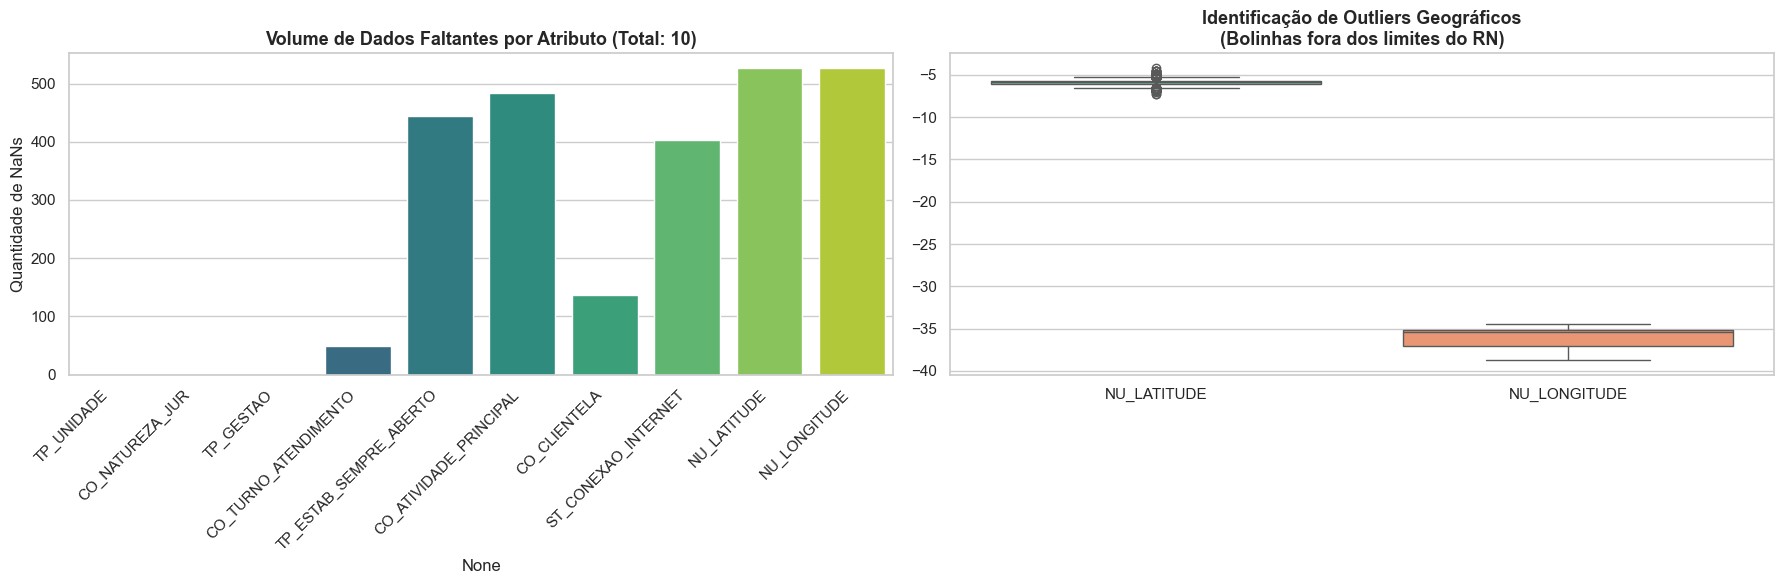


--- TABELA RESUMO ---


,Atributo,Total NaNs,% Faltante
0,TP_UNIDADE,0,0.00
1,CO_NATUREZA_JUR,0,0.00
2,TP_GESTAO,0,0.00
3,CO_TURNO_ATENDIMENTO,49,0.66
4,TP_ESTAB_SEMPRE_ABERTO,445,5.97
5,CO_ATIVIDADE_PRINCIPAL,484,6.50
6,CO_CLIENTELA,137,1.84
7,ST_CONEXAO_INTERNET,403,5.41
8,NU_LATITUDE,526,7.06
9,NU_LONGITUDE,526,7.06



FATO IMPORTANTE:
Serão removidas as 526 linhas sem coordenadas.


In [4]:
#Célula 3: Análise da Qualidade de Dados:
print("--- PREPARANDO DADOS PARA DIAGNÓSTICO ---")

#Tratando as coordenadas ANTES do diagnóstico:
for col in ['NU_LATITUDE', 'NU_LONGITUDE']:
    df_analise[col] = pd.to_numeric(df_analise[col].astype(str).str.replace(',', '.'), errors='coerce')

#Separando todas as colunas selecionadas:
colunas_10 = [
    'TP_UNIDADE', 'CO_NATUREZA_JUR', 'TP_GESTAO', 'CO_TURNO_ATENDIMENTO',
    'TP_ESTAB_SEMPRE_ABERTO', 'CO_ATIVIDADE_PRINCIPAL', 'CO_CLIENTELA',
    'ST_CONEXAO_INTERNET', 'NU_LATITUDE', 'NU_LONGITUDE'
]

plt.figure(figsize=(18, 6))


# Subplot 1: Gráfico de Barras (Obrigando a mostrar as 10 colunas)
plt.subplot(1, 2, 1)
nulos_10 = df_analise[colunas_10].isnull().sum()
# Usamos barplot do seaborn para um visual mais profissional
sns.barplot(x=nulos_10.index, y=nulos_10.values, hue=nulos_10.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Volume de Dados Faltantes por Atributo (Total: 10)', fontsize=13, fontweight='bold')
plt.ylabel('Quantidade de NaNs')

# Subplot 2: Boxplot de Outliers (Para identificar as bolinhas do mapa)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_analise[['NU_LATITUDE', 'NU_LONGITUDE']], palette="Set2")
plt.title('Identificação de Outliers Geográficos\n(Bolinhas fora dos limites do RN)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('diagnostico_qualidade_dados.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- TABELA RESUMO ---")
resumo_nulos = pd.DataFrame({
    'Atributo': colunas_10,
    'Total NaNs': nulos_10.values,
    '% Faltante': (nulos_10.values / len(df_analise) * 100).round(2)
})
display(resumo_nulos)

nulos_gps = nulos_10['NU_LATITUDE']

print(f"\nFATO IMPORTANTE:")
print(f"Serão removidas as {nulos_gps} linhas sem coordenadas.")

--- CONSOLIDANDO A BASE FINAL ---


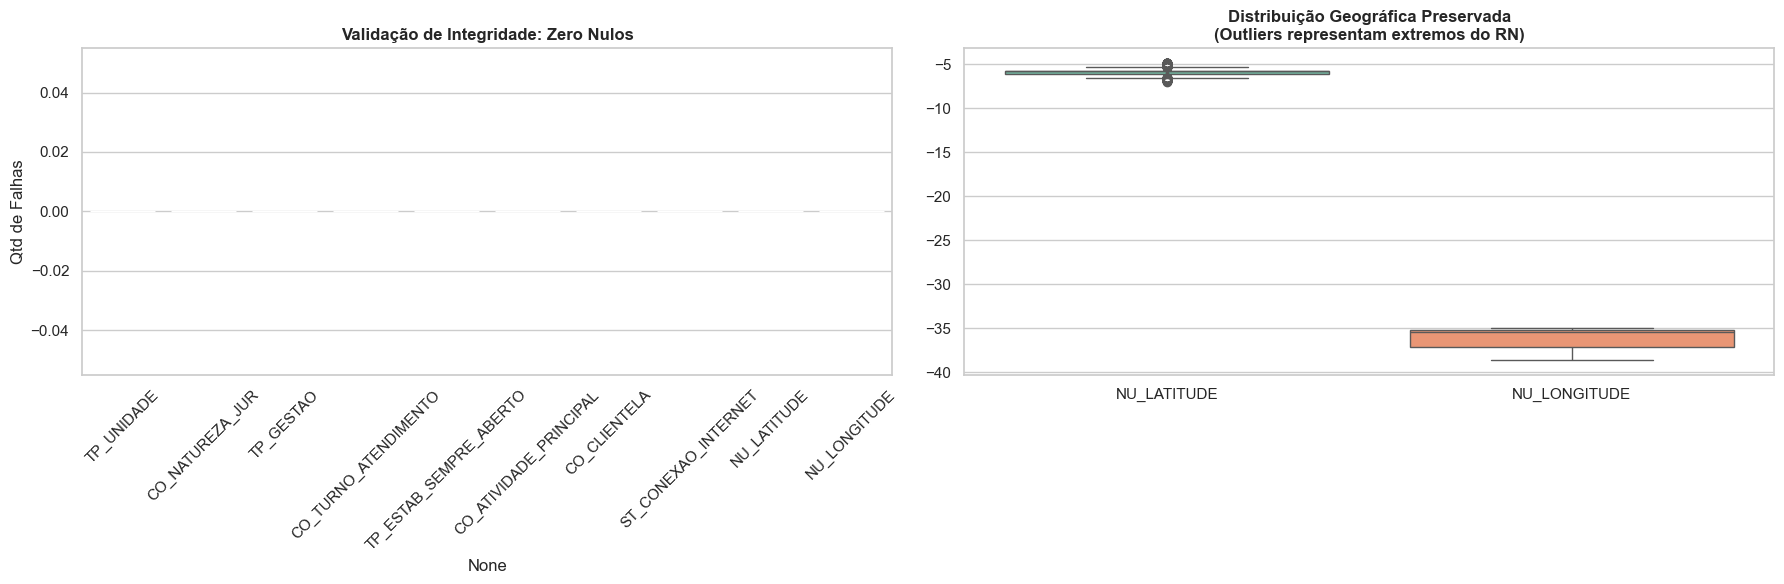

Base pronta: 6910 registros sem nulos.


In [5]:
#Célula 4: Consolidação da Base e Justificativa Técnica
print("--- CONSOLIDANDO A BASE FINAL ---")

#Limpeza de nulos nas coordenadas (Removendo apenas o que é nulo ou fora do quadrado do RN):
df_limpo = df_analise.dropna(subset=['NU_LATITUDE', 'NU_LONGITUDE']).copy()

#Limites amplos que garantem o RN todo mas tiram o 'lixo' de fora
df_limpo = df_limpo[
    (df_limpo['NU_LATITUDE'] <= -4.8) & (df_limpo['NU_LATITUDE'] >= -7.1) &
    (df_limpo['NU_LONGITUDE'] <= -34.7) & (df_limpo['NU_LONGITUDE'] >= -38.6)
]

#Tratando nulos restantes com a moda:
for col in df_limpo.columns:
    if df_limpo[col].isnull().sum() > 0:
        df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mode()[0])

# --- VISUALIZAÇÃO PARA O ARTIGO ---
plt.figure(figsize=(18, 6))

#Subplot 1: Prova de que não há mais NULOS
plt.subplot(1, 2, 1)
nulos_finais = df_limpo[colunas_10].isnull().sum()
sns.barplot(x=nulos_finais.index, y=nulos_finais.values, color='seagreen')
plt.title('Validação de Integridade: Zero Nulos', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Qtd de Falhas')

#Subplot 2: O Boxplot que prova a preservação do interior
plt.subplot(1, 2, 2)
sns.boxplot(data=df_limpo[['NU_LATITUDE', 'NU_LONGITUDE']], palette="Set2")
plt.title('Distribuição Geográfica Preservada\n(Outliers representam extremos do RN)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('tratamento_qualidade_dados_final.png', dpi=300)
plt.show()

# Tabela Final para o "Check"
print(f"Base pronta: {len(df_limpo)} registros sem nulos.")

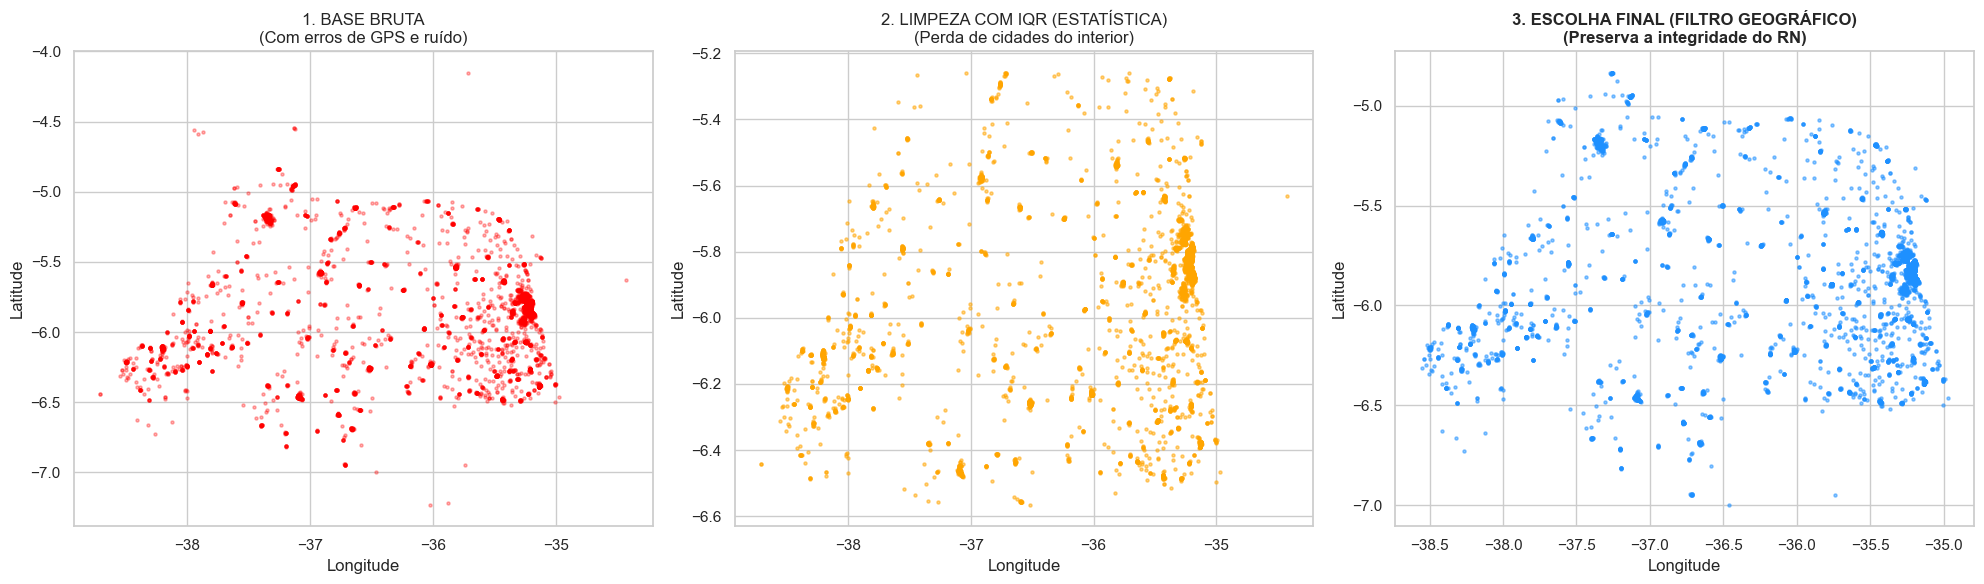

📊 Análise de Amostra:
- Base Bruta: 6922 postos
- Após IQR: 5841 postos (Perda excessiva!)
- Nossa Escolha: 6910 postos (Equilíbrio ideal)


In [6]:
#Célula 4.2: Comparativo de uso de IRQ para limpeza de outliers
df_original_geo = df_analise.dropna(subset=['NU_LATITUDE', 'NU_LONGITUDE']).copy()

#Cenário A: Limpeza com IQR (A que "corta" o estado)
Q1 = df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']].quantile(0.25)
Q3 = df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df_original_geo[~((df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']] < (Q1 - 1.5 * IQR)) |
                           (df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']] > (Q3 + 1.5 * IQR))).any(axis=1)]

#Cenário B: Escolha Final (Filtro Geográfico Real - df_limpo que já temos)

#Plotagem Tripla para o Artigo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#Mapa 1: Base Bruta sem tratamento
axes[0].scatter(df_original_geo['NU_LONGITUDE'], df_original_geo['NU_LATITUDE'], s=5, color='red', alpha=0.3)
axes[0].set_title('1. BASE BRUTA\n(Com erros de GPS e ruído)', fontsize=12)

#Mapa 2: Limpeza com IQR
axes[1].scatter(df_iqr['NU_LONGITUDE'], df_iqr['NU_LATITUDE'], s=5, color='orange', alpha=0.5)
axes[1].set_title('2. LIMPEZA COM IQR (ESTATÍSTICA)\n(Perda de cidades do interior)', fontsize=12)

#Mapa 3: Escolha Final com limpeza suave
axes[2].scatter(df_limpo['NU_LONGITUDE'], df_limpo['NU_LATITUDE'], s=5, color='dodgerblue', alpha=0.5)
axes[2].set_title('3. ESCOLHA FINAL (FILTRO GEOGRÁFICO)\n(Preserva a integridade do RN)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('justificativa_metodologica_mapas.png', dpi=300)
plt.show()

print(f"📊 Análise de Amostra:")
print(f"- Base Bruta: {len(df_original_geo)} postos")
print(f"- Após IQR: {len(df_iqr)} postos (Perda excessiva!)")
print(f"- Nossa Escolha: {len(df_limpo)} postos (Equilíbrio ideal)")

In [7]:
#Célula 5: Transformação de Dados (One-Hot vs Frequency)
print("--- INICIANDO ENCODINGS ---")

#Definindo as colunas categóricas (texto) e as numéricas (coordenadas)
cols_cat = [c for c in df_limpo.columns if c not in ['NU_LATITUDE', 'NU_LONGITUDE']]

#Aplicando a lógica de "Top 5 + Outros" para One Hot Encoding:
df_top5 = df_limpo.copy()
for col in cols_cat:
    top_5 = df_top5[col].value_counts().nlargest(5).index
    df_top5[col] = df_top5[col].where(df_top5[col].isin(top_5), 'Outros')

df_onehot = pd.get_dummies(df_top5, columns=cols_cat, dtype=int)

#Aplicando Normalização no One Hot:
scaler_oh = StandardScaler()
df_final_onehot = pd.DataFrame(scaler_oh.fit_transform(df_onehot), columns=df_onehot.columns)


#FREQUENCY ENCODING (Baseado nos dados originais) ---
df_freq = df_limpo.copy()
for col in cols_cat:
    freq_map = df_freq[col].value_counts(normalize=True)
    df_freq[col] = df_freq[col].map(freq_map)

#Aplicando Normalização no Freq:
scaler_fr = StandardScaler()
df_final_freq = pd.DataFrame(scaler_fr.fit_transform(df_freq), columns=df_freq.columns)


#Exportação dos Arquivos para a Fase de Clusterização:
df_final_onehot.to_csv('base_sus_rn_onehot.csv', index=False)
df_final_freq.to_csv('base_sus_rn_frequencia.csv', index=False)

print(f"Base One-Hot: {df_final_onehot.shape[1]} colunas | Salva como 'base_sus_rn_onehot.csv'")
print(f"Base Frequência: {df_final_freq.shape[1]} colunas | Salva como 'base_sus_rn_frequencia.csv'")

#Visualização das tabelas:
display(df_final_onehot.head())
display(df_final_freq.head())

--- INICIANDO ENCODINGS ---
Base One-Hot: 36 colunas | Salva como 'base_sus_rn_onehot.csv'
Base Frequência: 10 colunas | Salva como 'base_sus_rn_frequencia.csv'


,NU_LATITUDE,NU_LONGITUDE,TP_UNIDADE_2,TP_UNIDADE_22,TP_UNIDADE_36,TP_UNIDADE_39,TP_UNIDADE_43,TP_UNIDADE_Outros,CO_NATUREZA_JUR_1031.0,CO_NATUREZA_JUR_1244.0,...,CO_ATIVIDADE_PRINCIPAL_2.0,CO_ATIVIDADE_PRINCIPAL_8.0,CO_ATIVIDADE_PRINCIPAL_12.0,CO_ATIVIDADE_PRINCIPAL_22.0,CO_ATIVIDADE_PRINCIPAL_Outros,CO_CLIENTELA_1.0,CO_CLIENTELA_2.0,CO_CLIENTELA_3.0,ST_CONEXAO_INTERNET_N,ST_CONEXAO_INTERNET_S
0,0.133843,0.831550,-0.432057,-0.605105,-0.539543,3.668251,-0.271996,-0.517356,-0.160721,-0.710717,...,3.341481,-0.238872,-0.476130,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417
1,2.347688,-1.049414,-0.432057,-0.605105,-0.539543,-0.272609,-0.271996,1.932905,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,0.978240,-0.212668,-0.896759,3.082454,-3.082454
2,2.360506,-1.043737,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,3.082454,-3.082454
3,-0.887255,0.788855,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417
4,-0.951216,0.885763,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417


,TP_UNIDADE,CO_NATUREZA_JUR,TP_GESTAO,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,CO_ATIVIDADE_PRINCIPAL,CO_CLIENTELA,ST_CONEXAO_INTERNET,NU_LATITUDE,NU_LONGITUDE
0,-0.947915,0.645234,0.147942,0.493477,0.271382,-0.989971,-0.168634,0.324417,0.133843,0.831550
1,-1.190955,0.657617,0.147942,0.493477,0.271382,-0.485018,0.521981,-3.082454,2.347688,-1.049414
2,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,-3.082454,2.360506,-1.043737
3,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,0.324417,-0.887255,0.788855
4,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,0.324417,-0.951216,0.885763


--- AMOSTRA DA BASE ANTES DO ENCODING ---


,TP_UNIDADE,CO_NATUREZA_JUR,TP_GESTAO,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,CO_ATIVIDADE_PRINCIPAL,CO_CLIENTELA,ST_CONEXAO_INTERNET,NU_LATITUDE,NU_LONGITUDE
14,39,2062.0,M,3.0,N,2.0,3.0,S,-5.786853,-35.195943
269,1,1244.0,M,3.0,N,12.0,1.0,N,-4.956152,-37.136922
270,2,1244.0,M,3.0,N,12.0,3.0,N,-4.951342,-37.131064
271,2,1244.0,M,3.0,N,12.0,3.0,S,-6.170000,-35.240000
272,2,1244.0,M,3.0,N,12.0,3.0,S,-6.194000,-35.140000
647,1,1244.0,M,3.0,N,12.0,3.0,S,-6.091679,-35.399242
721,43,2046.0,M,3.0,N,8.0,1.0,S,-5.777962,-35.249158
782,36,2062.0,M,3.0,N,1.0,3.0,S,-5.794849,-35.217765
805,2,1244.0,M,3.0,N,12.0,1.0,S,-5.170233,-37.028968
877,36,2062.0,M,5.0,N,1.0,3.0,S,-6.264739,-35.208911


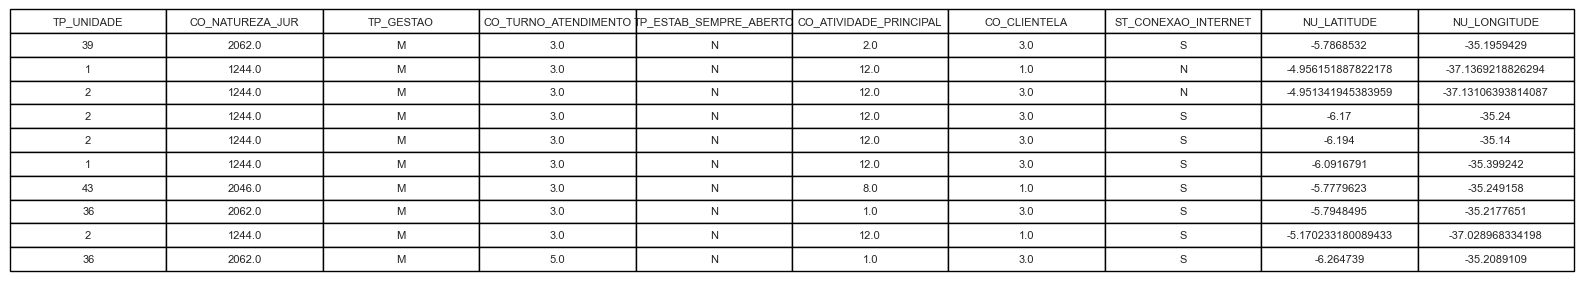

Imagem salva como 'amostra_atributos.png'


In [23]:
#Célula 5.1: Amostragem Visual da Base — 10 primeiros registros
print("--- AMOSTRA DA BASE ANTES DO ENCODING ---")

# Exibe os 10 primeiros registros dos 10 atributos selecionados
amostra = df_limpo[colunas_selecionadas].head(10)
display(amostra)

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')
tabela = ax.table(cellText=amostra.values, colLabels=amostra.columns,
                  loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1, 1.5)
plt.tight_layout()
plt.savefig('amostra_atributos.png', dpi=200, bbox_inches='tight')
plt.show()
print("Imagem salva como 'amostra_atributos.png'")

In [8]:
#Célula 6: Tratamento do One Hot Encoding com Kmeans
print("\n--- FASE 2: Iniciando tratamento com K-Means (Iniciando processamento em lote) ---")

#Carregando a base com One Hot Encoding:
df_projeto = pd.read_csv('base_sus_rn_onehot.csv')

#Dicionário para guardar as notas de cada teste:
resultados_kmeans = {
    'k': [],
    'silhouette_kpp': [], 'db_kpp': [],
    'silhouette_random': [], 'db_random': []
}

print("\nIniciando o loop do K-Means (k variando de 2 a 10)...")

#O Loop entre 2 e 10 Ks.
for k in range(2, 11):
    # Execução A: init = 'k-means++' (Exigência do PDF)
    model_kpp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_kpp = model_kpp.fit_predict(df_projeto)

    # Execução B: init = 'random' (Exigência do PDF)
    model_rnd = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_rnd = model_rnd.fit_predict(df_projeto)

    # Armazenando os resultados para a Análise Comparativa posterior
    resultados_kmeans['k'].append(k)

    # Métricas para k-means++
    resultados_kmeans['silhouette_kpp'].append(silhouette_score(df_projeto, labels_kpp))
    resultados_kmeans['db_kpp'].append(davies_bouldin_score(df_projeto, labels_kpp))

    # Métricas para random
    resultados_kmeans['silhouette_random'].append(silhouette_score(df_projeto, labels_rnd))
    resultados_kmeans['db_random'].append(davies_bouldin_score(df_projeto, labels_rnd))

    print(f"Finalizado K={k}")

print(f"\nEtapa com K-Means finalizado com sucesso")

#Convertendo os resultados e salvando num CSV de segurança:
df_res_kmeans = pd.DataFrame(resultados_kmeans)
df_res_kmeans.to_csv('resultados_kmeans_sus.csv', index=False)
print("As notas foram salvas no arquivo 'resultados_kmeans_sus.csv'.")


--- FASE 2: Iniciando tratamento com K-Means (Iniciando processamento em lote) ---

Iniciando o loop do K-Means (k variando de 2 a 10)...
Finalizado K=2
Finalizado K=3
Finalizado K=4
Finalizado K=5
Finalizado K=6
Finalizado K=7
Finalizado K=8
Finalizado K=9
Finalizado K=10

Etapa com K-Means finalizado com sucesso
As notas foram salvas no arquivo 'resultados_kmeans_sus.csv'.


In [9]:
#Célula 7: Tratamento do One Hot Encoding com Hierarquico
print("\n--- EXECUTANDO HIERÁRQUICO AGLOMERATIVO (2 A 10 GRUPOS) ---")

df_projeto = pd.read_csv('base_sus_rn_onehot.csv')

#Dicionário para guardar as métricas exigidas (Silhouette e Davies-Bouldin)
resultados_hc = {
    'k': [],
    'linkage': [],
    'silhouette': [],
    'db': []
}


#Tipos de ligação:
linkages = ['ward', 'complete', 'average', 'single']

print("\nIniciando a construção dos dendrogramas...")

#Loop duplo conforme exigência do K de 2 a 10
for k in range(2, 11):
    for link in linkages:
        # Criando e treinando o modelo
        #Nota: O Hierárquico não tem 'random_state' pois é determinístico
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(df_projeto)

        #Armazenando resultados:
        resultados_hc['k'].append(k)
        resultados_hc['linkage'].append(link)
        resultados_hc['silhouette'].append(silhouette_score(df_projeto, labels))
        resultados_hc['db'].append(davies_bouldin_score(df_projeto, labels))

    print(f"Finalizado K={k} para todos os linkages.")

#Exportando para o CSV:
df_res_hc = pd.DataFrame(resultados_hc)
df_res_hc.to_csv('resultados_hierarquico_sus.csv', index=False)


--- EXECUTANDO HIERÁRQUICO AGLOMERATIVO (2 A 10 GRUPOS) ---

Iniciando a construção dos dendrogramas...
Finalizado K=2 para todos os linkages.
Finalizado K=3 para todos os linkages.
Finalizado K=4 para todos os linkages.
Finalizado K=5 para todos os linkages.
Finalizado K=6 para todos os linkages.
Finalizado K=7 para todos os linkages.
Finalizado K=8 para todos os linkages.
Finalizado K=9 para todos os linkages.
Finalizado K=10 para todos os linkages.


In [10]:
#Célula 8: Tratamento do One Hot Encoding com EM (gaussiano)
print("\n--- FASE 2: EXECUTANDO EXPECTATION-MAXIMIZATION (EM) ---")

#Carregando a base com One Hot Encoding:
df_projeto = pd.read_csv('base_sus_rn_onehot.csv')

#Dicionário para guardar as notas:
resultados_em = {
    'k': [],
    'covariance_type': [],
    'silhouette': [],
    'db': []
}

covariances = ['full', 'tied', 'diag', 'spherical']

print("\nIniciando o treinamento dos modelos EM...")
inicio_tempo = time.time()

#Loop duplo: variando o k e o formato da covariância:
for k in range(2, 11):
    for cov in covariances:
        # Criando e treinando o modelo GMM (representação do EM no sklearn)
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)

        # O fit_predict gera os rótulos (labels) para cada posto de saúde
        labels = gmm.fit_predict(df_projeto)

        # Armazenando os resultados para a análise comparativa
        resultados_em['k'].append(k)
        resultados_em['covariance_type'].append(cov)
        resultados_em['silhouette'].append(silhouette_score(df_projeto, labels))
        resultados_em['db'].append(davies_bouldin_score(df_projeto, labels))

    print(f"Finalizado K={k} para todos os tipos de covariância.")

print(f"\nExpectation Maximization (EM) finalizado com sucesso!")

#Exportando os resultados finais da Fase 2:
df_res_em = pd.DataFrame(resultados_em)
df_res_em.to_csv('resultados_em_sus.csv', index=False)
print("As notas foram salvas no arquivo 'resultados_em_sus.csv'.\nA Fase 2 está finalizada!")


--- FASE 2: EXECUTANDO EXPECTATION-MAXIMIZATION (EM) ---

Iniciando o treinamento dos modelos EM...
Finalizado K=2 para todos os tipos de covariância.
Finalizado K=3 para todos os tipos de covariância.
Finalizado K=4 para todos os tipos de covariância.
Finalizado K=5 para todos os tipos de covariância.
Finalizado K=6 para todos os tipos de covariância.
Finalizado K=7 para todos os tipos de covariância.
Finalizado K=8 para todos os tipos de covariância.
Finalizado K=9 para todos os tipos de covariância.
Finalizado K=10 para todos os tipos de covariância.

Expectation Maximization (EM) finalizado com sucesso!
As notas foram salvas no arquivo 'resultados_em_sus.csv'.
A Fase 2 está finalizada!



--- FASE 3: Validação Visual (Resultados K-Means com One-Hot) ---



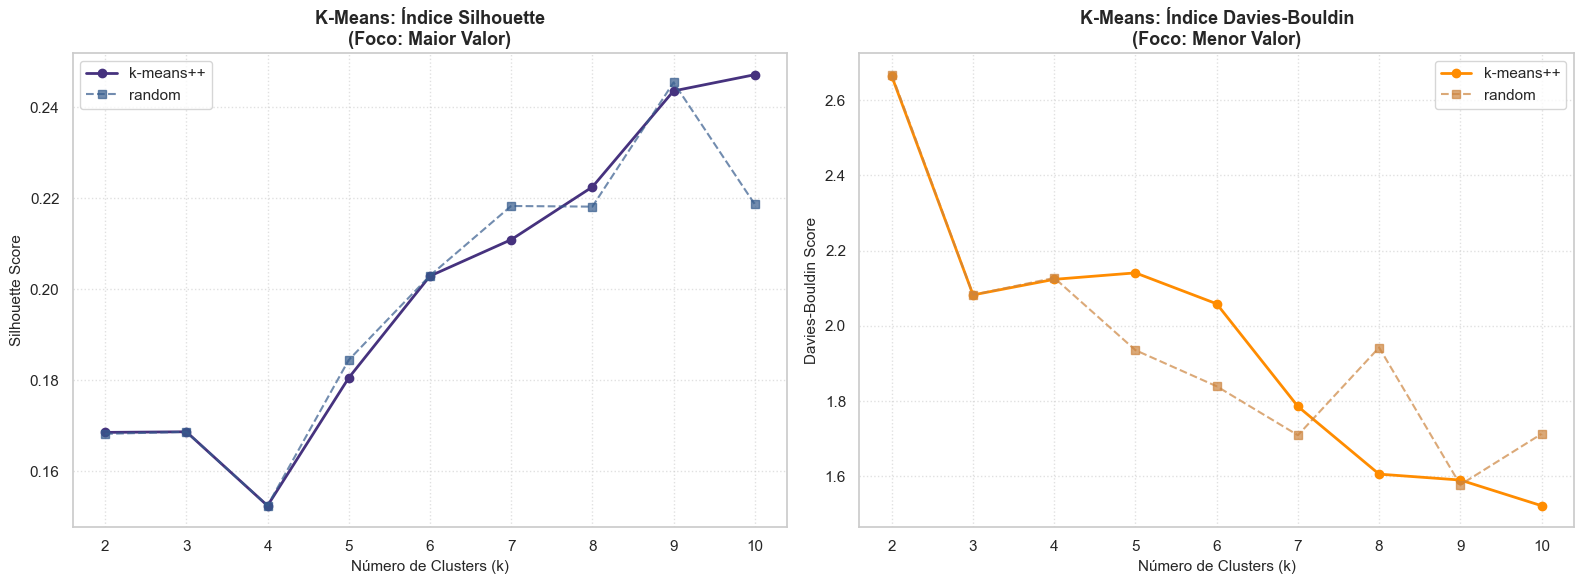

In [11]:
#Célula 09: Começando a plotar as imagens para comparativos
print("\n--- FASE 3: Validação Visual (Resultados K-Means com One-Hot) ---\n")

#Carregando os resultados gerados:
df_kmeans = pd.read_csv('resultados_kmeans_sus.csv')

#Configurando a tela de desenho:
plt.figure(figsize=(16, 6))


# Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
plt.plot(df_kmeans['k'], df_kmeans['silhouette_kpp'], marker='o', linewidth=2, label='k-means++')
plt.plot(df_kmeans['k'], df_kmeans['silhouette_random'], marker='s', linestyle='--', alpha=0.7, label='random')

plt.title('K-Means: Índice Silhouette\n(Foco: Maior Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(df_kmeans['k'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')


# Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
plt.plot(df_kmeans['k'], df_kmeans['db_kpp'], marker='o', linewidth=2, color='darkorange', label='k-means++')
plt.plot(df_kmeans['k'], df_kmeans['db_random'], marker='s', linestyle='--', alpha=0.7, color='peru', label='random')

plt.title('K-Means: Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(df_kmeans['k'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')

#Ajuste de espaços e exibição final:
plt.tight_layout()
plt.savefig('grafico_fase3_kmeans-onehot.png', dpi=300, bbox_inches='tight')
plt.show()


--- FASE 3: Validação Visual (Resultados Hierárquico com One-Hot) ---



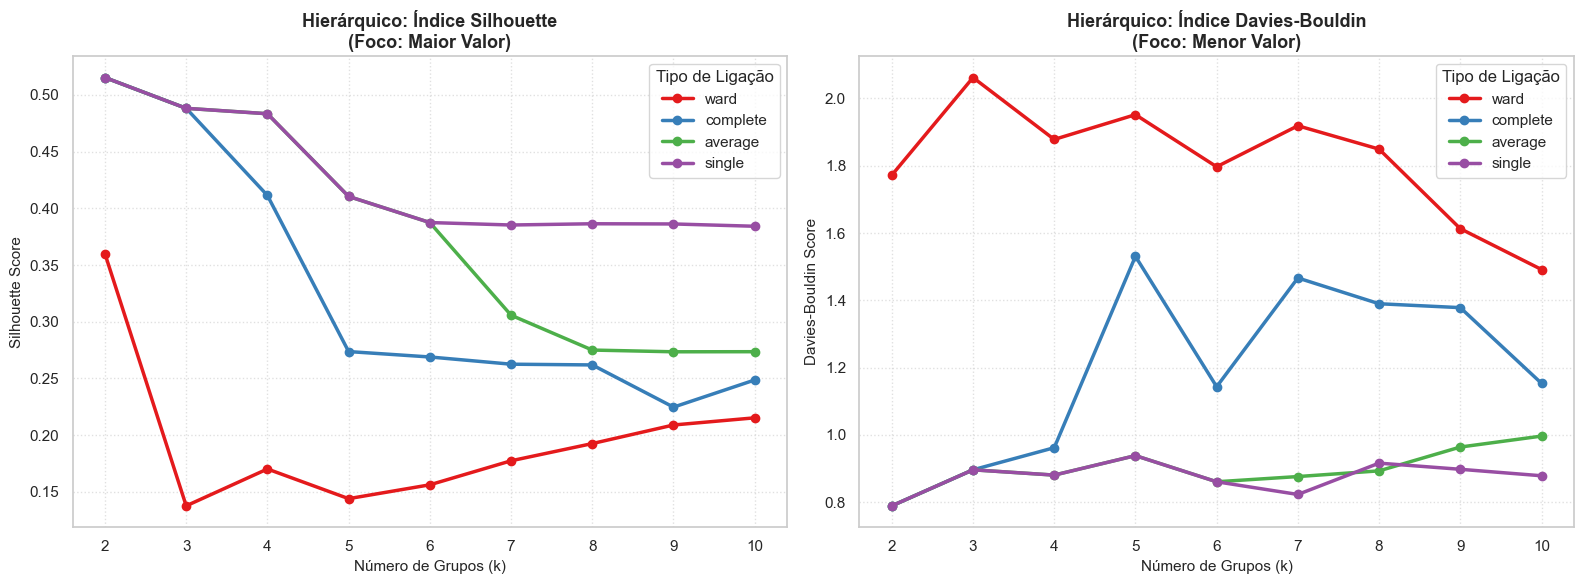

In [12]:
print("\n--- FASE 3: Validação Visual (Resultados Hierárquico com One-Hot) ---\n")

#Carregando os resultados do Hierárquico:
df_hc = pd.read_csv('resultados_hierarquico_sus.csv')
linkages = df_hc['linkage'].unique()

#Configurando a tela:
plt.figure(figsize=(16, 6))
colors = plt.cm.Set1(range(len(linkages)))


#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for i, link in enumerate(linkages):
    df_plot = df_hc[df_hc['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o',
             linewidth=2.5, label=link, color=colors[i])

plt.title('Hierárquico: Índice Silhouette\n(Foco: Maior Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Ligação", frameon=True)


#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for i, link in enumerate(linkages):
    df_plot = df_hc[df_hc['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['db'], marker='o',
             linewidth=2.5, label=link, color=colors[i])

plt.title('Hierárquico: Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Ligação", frameon=True)


plt.tight_layout()
plt.savefig('grafico_fase3_hierarquico-onehot.png', dpi=300, bbox_inches='tight')
plt.show()


--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture) ---



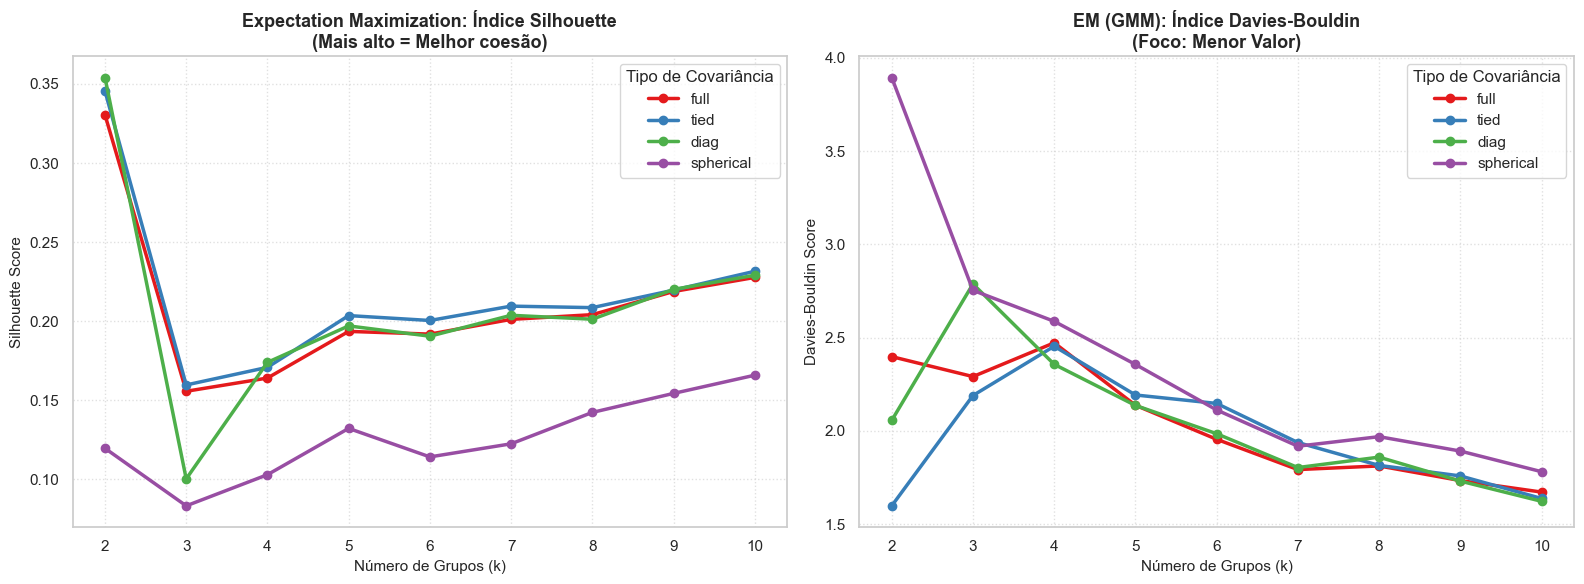

In [13]:
print("\n--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture) ---\n")

#Carregando os resultados do EM:
df_em = pd.read_csv('resultados_em_sus.csv')
covariances = df_em['covariance_type'].unique()

#Configurando a tela de desenho:
plt.figure(figsize=(16, 6))
colors = plt.cm.Set1(range(len(covariances)))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for i, cov in enumerate(covariances):
    df_plot = df_em[df_em['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o',
             linewidth=2.5, label=cov, color=colors[i])

plt.title('Expectation Maximization: Índice Silhouette\n(Mais alto = Melhor coesão)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Covariância", frameon=True)

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for i, cov in enumerate(covariances):
    df_plot = df_em[df_em['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['db'], marker='o',
             linewidth=2.5, label=cov, color=colors[i])

plt.title('EM (GMM): Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Covariância", frameon=True)

plt.tight_layout()
plt.savefig('grafico_fase3_em-onehot.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#Célula 12: Começando tratamento com Frequency Encoding:
print("\n--- FASE 2 (RODADA FREQUÊNCIA): K-Means ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de Frequência:
resultados_kmeans_freq = {
    'k': [],
    'silhouette_kpp': [], 'db_kpp': [],
    'silhouette_random': [], 'db_random': []
}

print("\nIniciando o loop do K-Means na base de Frequência (k de 2 a 10)...")

#O Loop de 2 a 10 Ks:
for k in range(2, 11):
    print(f"Treinando para k={k}...")

    #Teste A: init = 'k-means++'
    kmeans_kpp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_kpp = kmeans_kpp.fit_predict(df_freq)

    #Teste B: init = 'random'
    kmeans_random = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_random = kmeans_random.fit_predict(df_freq)

    #Salvando o K atual
    resultados_kmeans_freq['k'].append(k)

    #Calculando e guardando as notas do k-means++
    resultados_kmeans_freq['silhouette_kpp'].append(silhouette_score(df_freq, labels_kpp))
    resultados_kmeans_freq['db_kpp'].append(davies_bouldin_score(df_freq, labels_kpp))

    #Calculando e guardando as notas do random
    resultados_kmeans_freq['silhouette_random'].append(silhouette_score(df_freq, labels_random))
    resultados_kmeans_freq['db_random'].append(davies_bouldin_score(df_freq, labels_random))


print(f"\nK-Means com a base em Frequência finalizado com sucesso!")

#Salvando arquivo:
df_resultados_kmeans_freq = pd.DataFrame(resultados_kmeans_freq)
df_resultados_kmeans_freq.to_csv('resultados_kmeans_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_kmeans_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): K-Means ---


Iniciando o loop do K-Means na base de Frequência (k de 2 a 10)...
Treinando para k=2...
Treinando para k=3...
Treinando para k=4...
Treinando para k=5...
Treinando para k=6...
Treinando para k=7...
Treinando para k=8...
Treinando para k=9...
Treinando para k=10...

K-Means com a base em Frequência finalizado com sucesso!
Notas salvas no arquivo 'resultados_kmeans_sus_freq.csv'.


In [15]:
#Célula 13: Tratando com Frequency Encoding em Hierárquico:
print("\n--- FASE 2 (RODADA FREQUÊNCIA): Hierárquico Aglomerativo ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de Frequência:
resultados_hc_freq = {
    'k': [],
    'linkage': [],
    'silhouette': [],
    'db': []
}

linkages = ['ward', 'complete', 'average', 'single']

print("Iniciando a construção das árvores na base de Frequência...\n")

#O Loop duplo: variando o k e o tipo de ligação:
for k in range(2, 11):
    for link in linkages:
        print(f"Construindo árvore para k={k} usando linkage='{link}'...")

        #Criando e treinando o modelo (modelo determinístico, não usa random_state)
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(df_freq)

        #Salvando os resultados da rodada para análise de performance
        resultados_hc_freq['k'].append(k)
        resultados_hc_freq['linkage'].append(link)
        resultados_hc_freq['silhouette'].append(silhouette_score(df_freq, labels))
        resultados_hc_freq['db'].append(davies_bouldin_score(df_freq, labels))


print(f"\nHierárquico Aglomerativo com base em Frequência finalizado com sucesso!")


df_resultados_hc_freq = pd.DataFrame(resultados_hc_freq)
df_resultados_hc_freq.to_csv('resultados_hierarquico_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_hierarquico_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): Hierárquico Aglomerativo ---

Iniciando a construção das árvores na base de Frequência...

Construindo árvore para k=2 usando linkage='ward'...
Construindo árvore para k=2 usando linkage='complete'...
Construindo árvore para k=2 usando linkage='average'...
Construindo árvore para k=2 usando linkage='single'...
Construindo árvore para k=3 usando linkage='ward'...
Construindo árvore para k=3 usando linkage='complete'...
Construindo árvore para k=3 usando linkage='average'...
Construindo árvore para k=3 usando linkage='single'...
Construindo árvore para k=4 usando linkage='ward'...
Construindo árvore para k=4 usando linkage='complete'...
Construindo árvore para k=4 usando linkage='average'...
Construindo árvore para k=4 usando linkage='single'...
Construindo árvore para k=5 usando linkage='ward'...
Construindo árvore para k=5 usando linkage='complete'...
Construindo árvore para k=5 usando linkage='average'...
Construindo árvore para k=5 usando linkage='sin

In [16]:
#Célula 14: Tratando Frequency Encoding em Gaussian:
print("\n--- FASE 2 (RODADA FREQUÊNCIA): Expectation Maximization (EM) ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de EM:
resultados_em_freq = {
    'k': [],
    'covariance_type': [],
    'silhouette': [],
    'db': []
}

covariances = ['full', 'tied', 'diag', 'spherical']

print("Iniciando o loop do EM / Gaussian Mixture na base de Frequência...")
inicio_tempo = time.time()

#O Loop duplo: variando o k e a covariância:
for k in range(2, 11):
    for cov in covariances:
        print(f"Treinando modelo EM para k={k} com covariância='{cov}'...")

        #Criando e treinando o modelo (Gaussian Mixture é a implementação do EM no sklearn)
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)

        #Gerando os rótulos de grupo (labels)
        labels = gmm.fit_predict(df_freq)

        #Salvando os resultados da rodada para a métrica de comparação
        resultados_em_freq['k'].append(k)
        resultados_em_freq['covariance_type'].append(cov)
        resultados_em_freq['silhouette'].append(silhouette_score(df_freq, labels))
        resultados_em_freq['db'].append(davies_bouldin_score(df_freq, labels))


print(f"\nExpectation Maximization (Frequência) finalizado com sucesso!")

df_resultados_em_freq = pd.DataFrame(resultados_em_freq)
df_resultados_em_freq.to_csv('resultados_em_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_em_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): Expectation Maximization (EM) ---

Iniciando o loop do EM / Gaussian Mixture na base de Frequência...
Treinando modelo EM para k=2 com covariância='full'...
Treinando modelo EM para k=2 com covariância='tied'...
Treinando modelo EM para k=2 com covariância='diag'...
Treinando modelo EM para k=2 com covariância='spherical'...
Treinando modelo EM para k=3 com covariância='full'...
Treinando modelo EM para k=3 com covariância='tied'...
Treinando modelo EM para k=3 com covariância='diag'...
Treinando modelo EM para k=3 com covariância='spherical'...
Treinando modelo EM para k=4 com covariância='full'...
Treinando modelo EM para k=4 com covariância='tied'...
Treinando modelo EM para k=4 com covariância='diag'...
Treinando modelo EM para k=4 com covariância='spherical'...
Treinando modelo EM para k=5 com covariância='full'...
Treinando modelo EM para k=5 com covariância='tied'...
Treinando modelo EM para k=5 com covariância='diag'...
Treinando modelo EM para 

--- FASE 3: Validação Visual (Resultados K-Means com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_kmeans_freq.png'


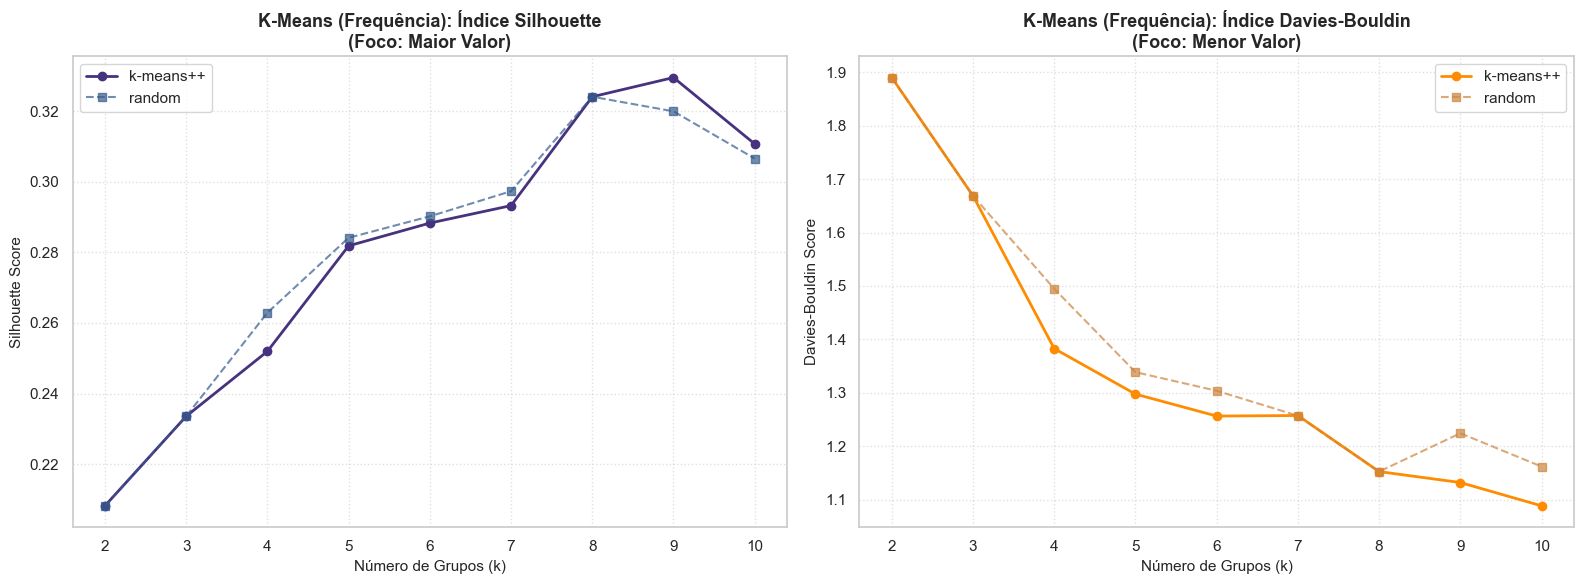

In [17]:
#Célula 15: Visualização K-Means (Rodada Frequency Encoding)

print("--- FASE 3: Validação Visual (Resultados K-Means com FREQUÊNCIA) ---")

#Carregando os resultados do Frequency Encoding:
df_kmeans_freq = pd.read_csv('resultados_kmeans_sus_freq.csv')

#Configurando a tela:
plt.figure(figsize=(16, 6))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['silhouette_kpp'], marker='o', linewidth=2, label='k-means++')
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['silhouette_random'], marker='s', linestyle='--', alpha=0.7, label='random')

plt.title('K-Means (Frequência): Índice Silhouette\n(Foco: Maior Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(df_kmeans_freq['k'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True)


#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['db_kpp'], marker='o', linewidth=2, color='darkorange', label='k-means++')
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['db_random'], marker='s', linestyle='--', alpha=0.7, color='peru', label='random')

plt.title('K-Means (Frequência): Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(df_kmeans_freq['k'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True)

plt.tight_layout()

#Salvando a imagem em alta resolução para o artigo!
plt.savefig('grafico_fase3_kmeans_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_kmeans_freq.png'")

plt.show()

--- FASE 3: Validação Visual (Resultados Hierárquico com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_hierarquico_freq.png'


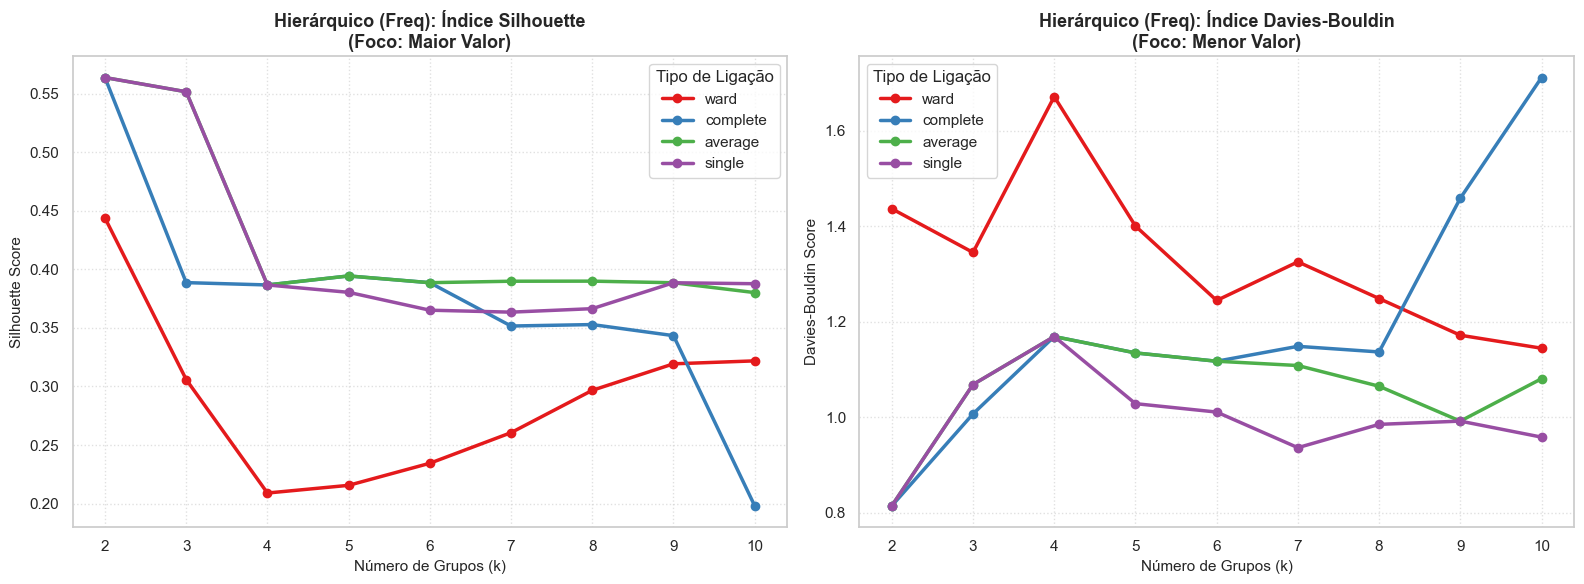

In [18]:
#Célula 16: Visualização Hierárquica (Rodada Frequency Encoding)

print("--- FASE 3: Validação Visual (Resultados Hierárquico com FREQUÊNCIA) ---")

#Carregando os resultados hierarquicos do Frequency Encoding:
df_hc_freq = pd.read_csv('resultados_hierarquico_sus_freq.csv')
linkages = df_hc_freq['linkage'].unique()

#Configurando a tela:
plt.figure(figsize=(16, 6))
colors = plt.cm.Set1(range(len(linkages)))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for i, link in enumerate(linkages):
    df_plot = df_hc_freq[df_hc_freq['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o',
             linewidth=2.5, label=link, color=colors[i])

plt.title('Hierárquico (Freq): Índice Silhouette\n(Foco: Maior Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Ligação", frameon=True)

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for i, link in enumerate(linkages):
    df_plot = df_hc_freq[df_hc_freq['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['db'], marker='o',
             linewidth=2.5, label=link, color=colors[i])

plt.title('Hierárquico (Freq): Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Ligação", frameon=True)

plt.tight_layout()

plt.savefig('grafico_fase3_hierarquico_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_hierarquico_freq.png'")

plt.show()

--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_em_freq.png'


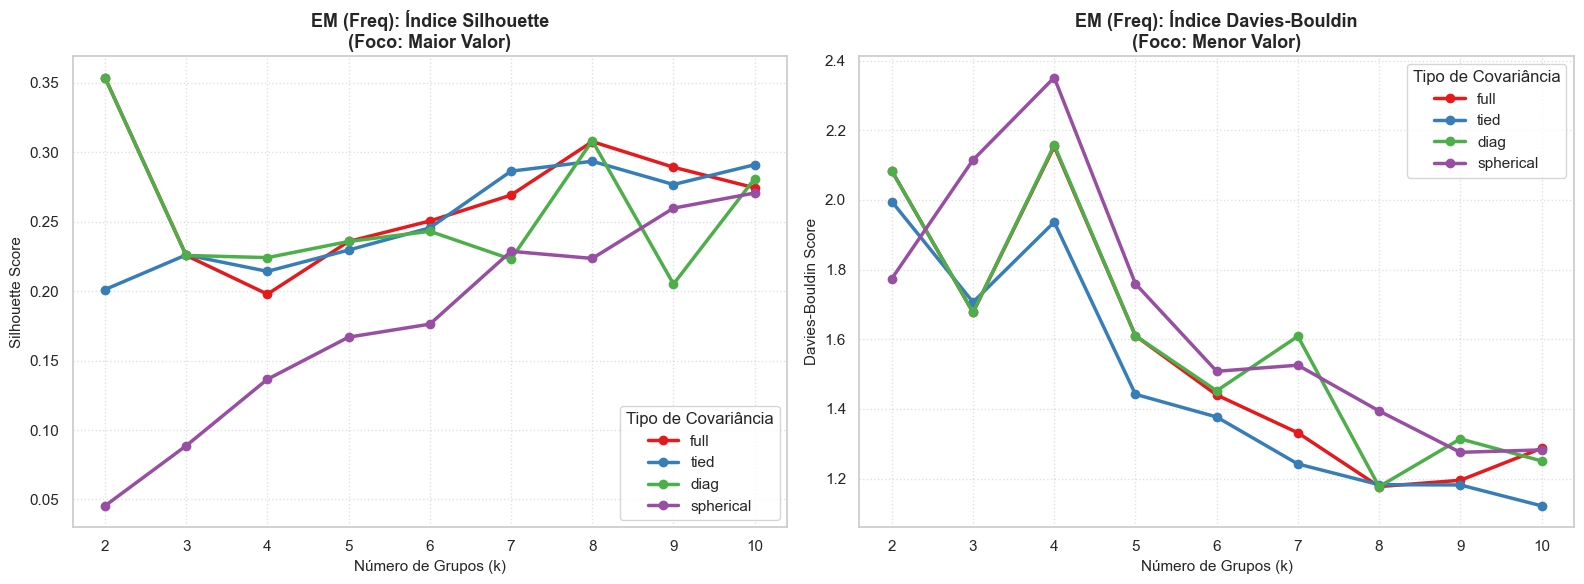

In [19]:
#Célula 17: Visualização EM / Gaussian Mixture (Rodada Frequency Encoding)
print("--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture com FREQUÊNCIA) ---")

#Carregando os resultados do EM (Frequency Encoding):
df_em_freq = pd.read_csv('resultados_em_sus_freq.csv')
covariances = df_em_freq['covariance_type'].unique()

#Configurando a tela de desenho:
plt.figure(figsize=(16, 6))
colors = plt.cm.Set1(range(len(covariances)))

#Gráfico 1: Índice Silhouette (Valor mais ALTO):
plt.subplot(1, 2, 1)
for i, cov in enumerate(covariances):
    df_plot = df_em_freq[df_em_freq['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o',
             linewidth=2.5, label=cov, color=colors[i])

plt.title('EM (Freq): Índice Silhouette\n(Foco: Maior Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Covariância", frameon=True)

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO):
plt.subplot(1, 2, 2)
for i, cov in enumerate(covariances):
    df_plot = df_em_freq[df_em_freq['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['db'], marker='o',
             linewidth=2.5, label=cov, color=colors[i])

plt.title('EM (Freq): Índice Davies-Bouldin\n(Foco: Menor Valor)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Grupos (k)', fontsize=11)
plt.ylabel('Davies-Bouldin Score', fontsize=11)
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de Covariância", frameon=True)

plt.tight_layout()

plt.savefig('grafico_fase3_em_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_em_freq.png'")

plt.show()

In [20]:
#Célula 18: Análise dos Grupos Vencedores (Perfil de cada cluster)
print("--- ANÁLISE DOS GRUPOS VENCEDORES ---")

# ── K-MEANS: k=9, k-means++, Frequency ──────────────────────────────────────
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')
df_original = df_limpo.copy()  # base original (antes do encoding) para interpretar

kmeans_final = KMeans(n_clusters=9, init='k-means++', n_init=10, random_state=42)
df_original['cluster_kmeans'] = kmeans_final.fit_predict(df_freq)

print("\n=== K-MEANS (k=9) — Tamanho de cada grupo ===")
print(df_original['cluster_kmeans'].value_counts().sort_index())

print("\n=== K-MEANS (k=9) — Perfil por grupo (moda dos atributos categóricos) ===")
cols_perfil = ['TP_UNIDADE','TP_GESTAO','CO_NATUREZA_JUR','CO_TURNO_ATENDIMENTO',
               'TP_ESTAB_SEMPRE_ABERTO','ST_CONEXAO_INTERNET']
perfil_kmeans = df_original.groupby('cluster_kmeans')[cols_perfil].agg(lambda x: x.mode()[0])
display(perfil_kmeans)

# ── HIERÁRQUICO: k=2, single, Frequency ─────────────────────────────────────
hc_final = AgglomerativeClustering(n_clusters=2, linkage='single')
df_original['cluster_hc'] = hc_final.fit_predict(df_freq)

print("\n=== HIERÁRQUICO (k=2, single) — Tamanho de cada grupo ===")
print(df_original['cluster_hc'].value_counts())

print("\n=== HIERÁRQUICO (k=2, single) — Perfil comparativo ===")
perfil_hc = df_original.groupby('cluster_hc')[cols_perfil].agg(lambda x: x.mode()[0])
display(perfil_hc)

# ── EM: k=2, diag, Frequency ────────────────────────────────────────────────
gmm_final = GaussianMixture(n_components=2, covariance_type='diag', random_state=42)
df_original['cluster_em'] = gmm_final.fit_predict(df_freq)

print("\n=== EM/GMM (k=2, diag) — Tamanho de cada grupo ===")
print(df_original['cluster_em'].value_counts())

print("\n=== EM/GMM (k=2, diag) — Perfil comparativo ===")
perfil_em = df_original.groupby('cluster_em')[cols_perfil].agg(lambda x: x.mode()[0])
display(perfil_em)

# Salvando os resultados com labels para uso nos próximos gráficos
df_original.to_csv('base_sus_com_clusters.csv', index=False)
print("\nBase com clusters salva em 'base_sus_com_clusters.csv'")

--- ANÁLISE DOS GRUPOS VENCEDORES ---

=== K-MEANS (k=9) — Tamanho de cada grupo ===
cluster_kmeans
0     369
1    1192
2    2064
3     670
4     815
5     601
6     148
7     783
8     268
Name: count, dtype: int64

=== K-MEANS (k=9) — Perfil por grupo (moda dos atributos categóricos) ===


,TP_UNIDADE,TP_GESTAO,CO_NATUREZA_JUR,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,ST_CONEXAO_INTERNET
cluster_kmeans,,,,,,
0,5,M,1244.0,6.0,S,S
1,2,M,1244.0,3.0,N,S
2,22,M,2062.0,3.0,N,S
3,22,M,4000.0,4.0,N,S
4,36,M,2062.0,3.0,N,S
5,2,M,1244.0,3.0,N,N
6,42,D,1023.0,6.0,S,S
7,2,M,1244.0,3.0,N,S
8,36,M,1244.0,3.0,N,S



=== HIERÁRQUICO (k=2, single) — Tamanho de cada grupo ===
cluster_hc
1    6762
0     148
Name: count, dtype: int64

=== HIERÁRQUICO (k=2, single) — Perfil comparativo ===


,TP_UNIDADE,TP_GESTAO,CO_NATUREZA_JUR,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,ST_CONEXAO_INTERNET
cluster_hc,,,,,,
0,42,D,1023.0,6.0,S,S
1,22,M,1244.0,3.0,N,S



=== EM/GMM (k=2, diag) — Tamanho de cada grupo ===
cluster_em
1    5773
0    1137
Name: count, dtype: int64

=== EM/GMM (k=2, diag) — Perfil comparativo ===


,TP_UNIDADE,TP_GESTAO,CO_NATUREZA_JUR,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,ST_CONEXAO_INTERNET
cluster_em,,,,,,
0,2,M,1244.0,3.0,N,N
1,22,M,2062.0,3.0,N,S



Base com clusters salva em 'base_sus_com_clusters.csv'


--- FINAL SCORE: JUSTIFICATIVA TÉCNICA DA ESCOLHA DO K ---
K-Means — Final Score por k:
 k  sil_best  db_best  final_score
 2  0.208175 1.889704     0.000000
 3  0.233554 1.668737     0.242410
 4  0.262900 1.382723     0.541745
 5  0.284141 1.297514     0.682402
 6  0.290218 1.256402     0.733088
 7  0.297340 1.256985     0.762060
 8  0.324121 1.152394     0.937636
 9  0.329555 1.131974     0.972760
10  0.310743 1.088315     0.922509
>> K vencedor: k=9 (score=0.9728)

Hierárquico — Top 5 configurações por Final Score:
 k  linkage  silhouette       db  final_score
 2 complete    0.563941 0.814130     1.000000
 2  average    0.563941 0.814130     1.000000
 2   single    0.563941 0.814130     1.000000
 3  average    0.551784 1.068136     0.841763
 3   single    0.551784 1.068136     0.841763
>> Vencedor: k=2, linkage=complete (score=1.0000)

EM/GMM — Top 5 configurações por Final Score:
 k covariance_type  silhouette       db  final_score
 8            diag    0.308293 1.176651     0.9038

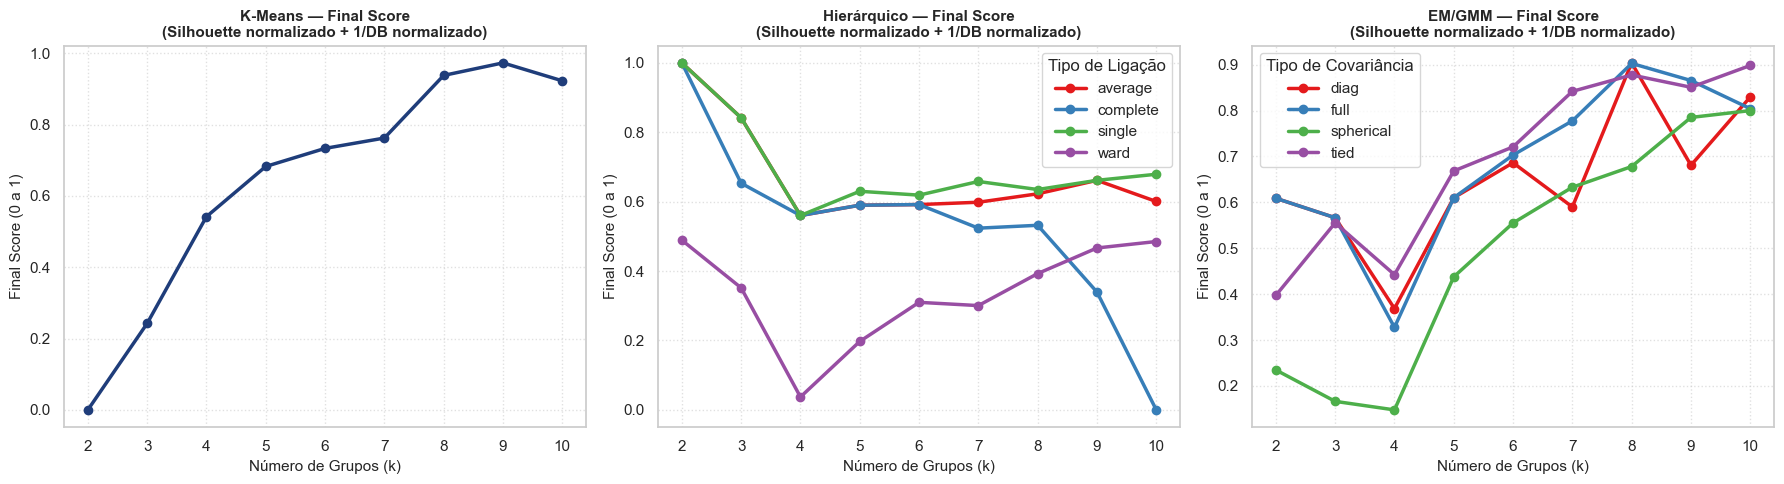

Gráfico salvo como 'grafico_final_score.png'


In [27]:
#Célula 19: Final Score Combinado para justificar escolha do K
print("--- FINAL SCORE: JUSTIFICATIVA TÉCNICA DA ESCOLHA DO K ---")

# Carregando os resultados salvos
df_km  = pd.read_csv('resultados_kmeans_sus_freq.csv')
df_hc  = pd.read_csv('resultados_hierarquico_sus_freq.csv')
df_em  = pd.read_csv('resultados_em_sus_freq.csv')

# ── K-Means: melhor combo por k ──────────────────────────────────────────────
# Para cada k, pega o maior silhouette e menor DB entre kpp e random
df_km['sil_best'] = df_km[['silhouette_kpp','silhouette_random']].max(axis=1)
df_km['db_best']  = df_km[['db_kpp','db_random']].min(axis=1)

# Normaliza: sil para [0,1] (maior = melhor), DB invertido para [0,1] (menor = melhor)
df_km['sil_norm'] = (df_km['sil_best'] - df_km['sil_best'].min()) / (df_km['sil_best'].max() - df_km['sil_best'].min())
df_km['db_norm']  = 1 - (df_km['db_best']  - df_km['db_best'].min())  / (df_km['db_best'].max()  - df_km['db_best'].min())
df_km['final_score'] = (df_km['sil_norm'] + df_km['db_norm']) / 2

print("K-Means — Final Score por k:")
print(df_km[['k','sil_best','db_best','final_score']].to_string(index=False))
print(f">> K vencedor: k={df_km.loc[df_km['final_score'].idxmax(), 'k']} (score={df_km['final_score'].max():.4f})")

# ── Hierárquico: melhor combo por k e linkage ─────────────────────────────────
df_hc_best = df_hc.copy()
df_hc_best['sil_norm'] = (df_hc['silhouette'] - df_hc['silhouette'].min()) / (df_hc['silhouette'].max() - df_hc['silhouette'].min())
df_hc_best['db_norm']  = 1 - (df_hc['db'] - df_hc['db'].min()) / (df_hc['db'].max() - df_hc['db'].min())
df_hc_best['final_score'] = (df_hc_best['sil_norm'] + df_hc_best['db_norm']) / 2

print("\nHierárquico — Top 5 configurações por Final Score:")
print(df_hc_best.nlargest(5, 'final_score')[['k','linkage','silhouette','db','final_score']].to_string(index=False))
venc = df_hc_best.loc[df_hc_best['final_score'].idxmax()]
print(f">> Vencedor: k={int(venc['k'])}, linkage={venc['linkage']} (score={venc['final_score']:.4f})")

# ── EM: melhor combo por k e covariância ─────────────────────────────────────
df_em_best = df_em.copy()
df_em_best['sil_norm'] = (df_em['silhouette'] - df_em['silhouette'].min()) / (df_em['silhouette'].max() - df_em['silhouette'].min())
df_em_best['db_norm']  = 1 - (df_em['db'] - df_em['db'].min()) / (df_em['db'].max() - df_em['db'].min())
df_em_best['final_score'] = (df_em_best['sil_norm'] + df_em_best['db_norm']) / 2

print("\nEM/GMM — Top 5 configurações por Final Score:")
print(df_em_best.nlargest(5, 'final_score')[['k','covariance_type','silhouette','db','final_score']].to_string(index=False))
venc_em = df_em_best.loc[df_em_best['final_score'].idxmax()]
print(f">> Vencedor: k={int(venc_em['k'])}, cov={venc_em['covariance_type']} (score={venc_em['final_score']:.4f})")

# ── Gráfico do Final Score — K-Means ─────────────────────────────────────────
colors_set1 = plt.cm.Set1(range(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── K-Means ───────────────────────────────────
axes[0].plot(df_km['k'], df_km['final_score'],
             marker='o', linewidth=2.5, color='#1f3d7a', label='k-means++')
axes[0].set_title('K-Means — Final Score\n(Silhouette normalizado + 1/DB normalizado)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Número de Grupos (k)', fontsize=11)
axes[0].set_ylabel('Final Score (0 a 1)', fontsize=11)
axes[0].set_xticks(range(2, 11))
axes[0].grid(True, linestyle=':', alpha=0.6)

# ── Hierárquico ──────────────────────
for i, (nome, grupo) in enumerate(df_hc_best.groupby('linkage')):
    axes[1].plot(grupo['k'], grupo['final_score'],
                 marker='o', linewidth=2.5, label=nome, color=colors_set1[i])
axes[1].set_title('Hierárquico — Final Score\n(Silhouette normalizado + 1/DB normalizado)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Número de Grupos (k)', fontsize=11)
axes[1].set_ylabel('Final Score (0 a 1)', fontsize=11)
axes[1].set_xticks(range(2, 11))
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(title="Tipo de Ligação", frameon=True)

# ── EM ────────────────────────────────
for i, (nome, grupo) in enumerate(df_em_best.groupby('covariance_type')):
    axes[2].plot(grupo['k'], grupo['final_score'],
                 marker='o', linewidth=2.5, label=nome, color=colors_set1[i])
axes[2].set_title('EM/GMM — Final Score\n(Silhouette normalizado + 1/DB normalizado)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Número de Grupos (k)', fontsize=11)
axes[2].set_ylabel('Final Score (0 a 1)', fontsize=11)
axes[2].set_xticks(range(2, 11))
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(title="Tipo de Covariância", frameon=True)

plt.tight_layout()
plt.savefig('grafico_final_score.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'grafico_final_score.png'")

--- VISUALIZAÇÃO 3D DOS CLUSTERS ---
Variância explicada pelos 3 componentes: 50.3%


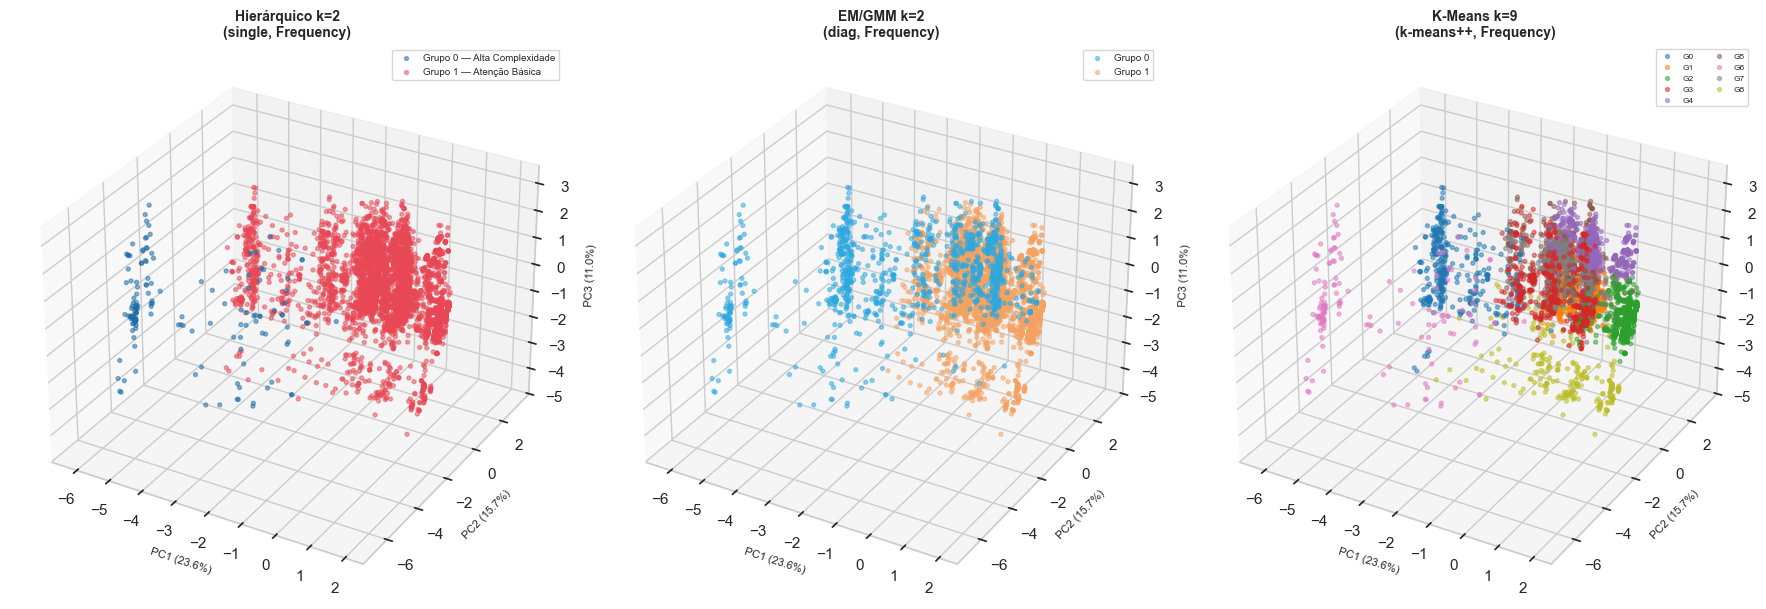

Gráfico 3D salvo como 'grafico_3d_clusters.png'


,TP_UNIDADE,TP_GESTAO,CO_NATUREZA_JUR,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,ST_CONEXAO_INTERNET,Qtd_estabelecimentos
Grupo 0,42,D,1023.0,6.0,S,S,148
Grupo 1,22,M,1244.0,3.0,N,S,6762


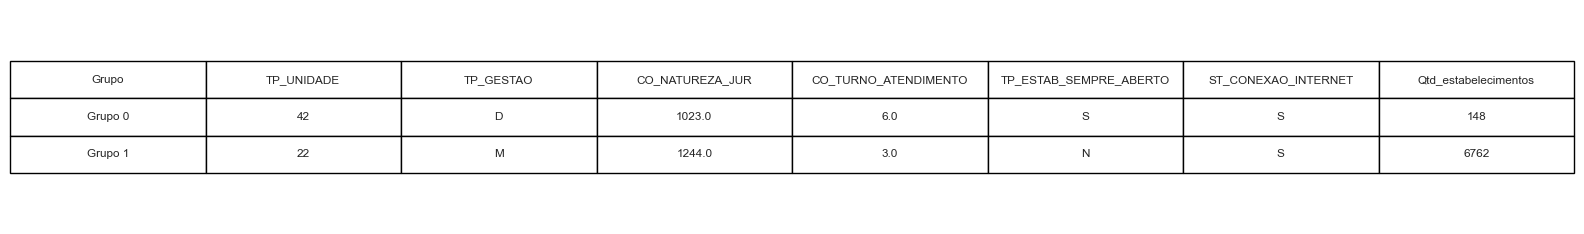

Tabela de perfil salva como 'tabela_perfil_grupos.png'


In [29]:
#Célula 20: Gráfico 3D dos grupos + tabela de perfil
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

print("--- VISUALIZAÇÃO 3D DOS CLUSTERS ---")

df_base_com_clusters = pd.read_csv('base_sus_com_clusters.csv')
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

# Redução para 3D com PCA
pca = PCA(n_components=3, random_state=42)
coords_3d = pca.fit_transform(df_freq)
variancia = pca.explained_variance_ratio_
print(f"Variância explicada pelos 3 componentes: {variancia.sum()*100:.1f}%")

# ── Plot 3D — Hierárquico k=2 ────────────────────────────────────────────────
colors_set1 = plt.cm.Set1(range(4))   # ward/complete/average/single | full/tied/diag/spherical
palette_9   = plt.cm.tab10(range(9))  # K-Means k=9

labels_hc = df_base_com_clusters['cluster_hc'].values
labels_em = df_base_com_clusters['cluster_em'].values
labels_km = df_base_com_clusters['cluster_kmeans'].values

fig = plt.figure(figsize=(18, 6))

labels_hc = df_base_com_clusters['cluster_hc'].values
cores_hc   = ['#1B6CA8','#E84855']
nomes_hc   = ['Grupo 0 — Alta Complexidade','Grupo 1 — Atenção Básica']

ax1 = fig.add_subplot(131, projection='3d')
for grupo, cor, nome in zip([0, 1], cores_hc, nomes_hc):
    mask = labels_hc == grupo
    ax1.scatter(coords_3d[mask,0], coords_3d[mask,1], coords_3d[mask,2],
                c=cor, s=8, alpha=0.5, label=nome)
ax1.set_title('Hierárquico k=2\n(single, Frequency)', fontsize=10, fontweight='bold')
ax1.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)', fontsize=8)
ax1.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)', fontsize=8)
ax1.set_zlabel(f'PC3 ({variancia[2]*100:.1f}%)', fontsize=8)
ax1.legend(fontsize=7)

# ── Plot 3D — EM k=2 ─────────────────────────────────────────────────────────
labels_em = df_base_com_clusters['cluster_em'].values
ax2 = fig.add_subplot(132, projection='3d')
for grupo, cor in zip([0, 1], ['#2EA8E0','#F4A261']):
    mask = labels_em == grupo
    ax2.scatter(coords_3d[mask,0], coords_3d[mask,1], coords_3d[mask,2],
                c=cor, s=8, alpha=0.5, label=f'Grupo {grupo}')
ax2.set_title('EM/GMM k=2\n(diag, Frequency)', fontsize=10, fontweight='bold')
ax2.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)', fontsize=8)
ax2.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)', fontsize=8)
ax2.set_zlabel(f'PC3 ({variancia[2]*100:.1f}%)', fontsize=8)
ax2.legend(fontsize=7)

# ── Plot 3D — K-Means k=9 ────────────────────────────────────────────────────
labels_km = df_base_com_clusters['cluster_kmeans'].values
palette_9 = plt.cm.tab10(range(9))
ax3 = fig.add_subplot(133, projection='3d')
for grupo in range(9):
    mask = labels_km == grupo
    ax3.scatter(coords_3d[mask,0], coords_3d[mask,1], coords_3d[mask,2],
                c=[palette_9[grupo]], s=8, alpha=0.5, label=f'G{grupo}')
ax3.set_title('K-Means k=9\n(k-means++, Frequency)', fontsize=10, fontweight='bold')
ax3.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)', fontsize=8)
ax3.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)', fontsize=8)
ax3.set_zlabel(f'PC3 ({variancia[2]*100:.1f}%)', fontsize=8)
ax3.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig('grafico_3d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 3D salvo como 'grafico_3d_clusters.png'")

# ── Tabela de perfil do Hierárquico k=2 (a mais interpretável) ───────────────
cols_perfil = ['TP_UNIDADE','TP_GESTAO','CO_NATUREZA_JUR',
               'CO_TURNO_ATENDIMENTO','TP_ESTAB_SEMPRE_ABERTO','ST_CONEXAO_INTERNET']
perfil_final = df_base_com_clusters.groupby('cluster_hc')[cols_perfil + ['NU_LATITUDE']].agg(
    {col: lambda x: x.mode()[0] for col in cols_perfil} | {'NU_LATITUDE': 'count'}
).rename(columns={'NU_LATITUDE': 'Qtd_estabelecimentos'})
perfil_final.index = ['Grupo 0', 'Grupo 1']
display(perfil_final)

# Salva a tabela como imagem
fig2, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')
tabela_plot = ax.table(
    cellText=perfil_final.reset_index().values,
    colLabels=['Grupo'] + list(perfil_final.columns),
    loc='center', cellLoc='center'
)
tabela_plot.auto_set_font_size(False)
tabela_plot.set_fontsize(8.5)
tabela_plot.scale(1, 2.0)
plt.tight_layout()
plt.savefig('tabela_perfil_grupos.png', dpi=200, bbox_inches='tight')
plt.show()
print("Tabela de perfil salva como 'tabela_perfil_grupos.png'")

--- MAPA DE CALOR: PERFIL MÉDIO POR CLUSTER ---


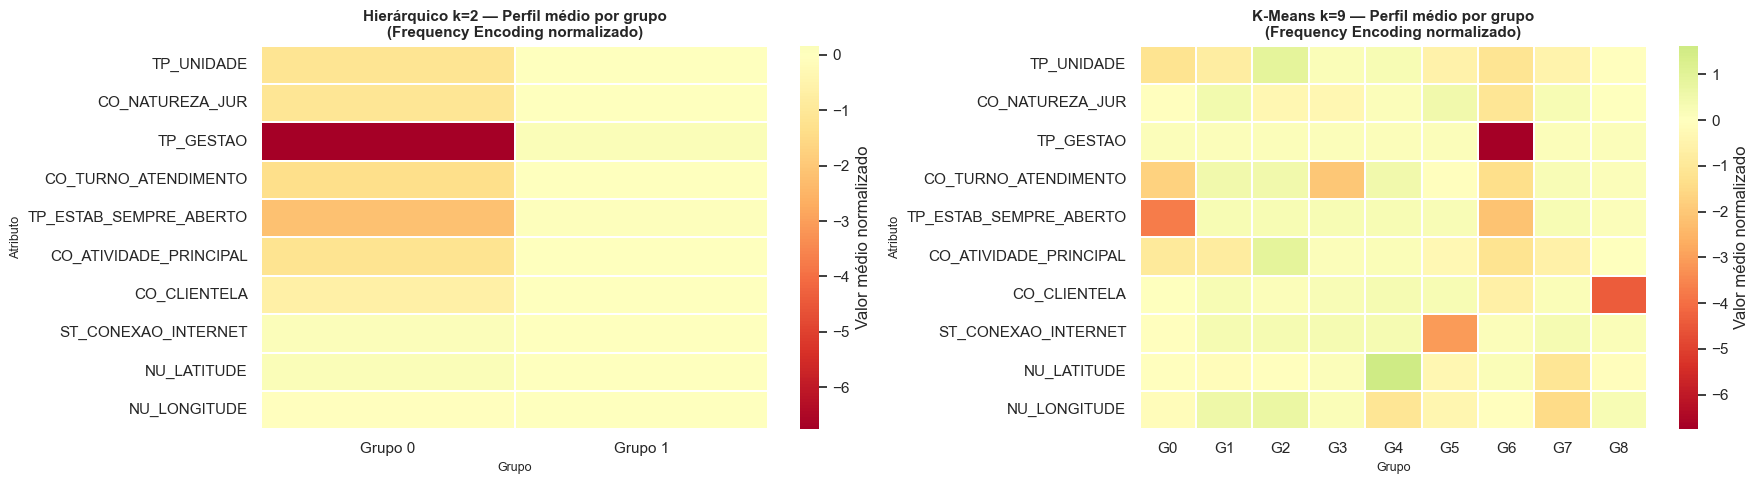

Mapa de calor salvo como 'heatmap_perfil_clusters.png'


In [26]:
#Célula 21: Mapa de Calor — Perfil numérico médio por cluster
print("--- MAPA DE CALOR: PERFIL MÉDIO POR CLUSTER ---")

df_base_com_clusters = pd.read_csv('base_sus_com_clusters.csv')
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

# Adiciona os labels ao dataframe de frequência (que tem os valores normalizados)
df_freq['cluster_hc'] = df_base_com_clusters['cluster_hc'].values
df_freq['cluster_km'] = df_base_com_clusters['cluster_kmeans'].values

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Heatmap Hierárquico k=2 ──────────────────────────────────────────────────
perfil_hc_num = df_freq.groupby('cluster_hc').mean(numeric_only=True).drop(
    columns=['cluster_hc','cluster_km'], errors='ignore')
perfil_hc_num.index = ['Grupo 0', 'Grupo 1']

sns.heatmap(perfil_hc_num.T, ax=axes[0], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, cbar_kws={'label': 'Valor médio normalizado'})
axes[0].set_title('Hierárquico k=2 — Perfil médio por grupo\n(Frequency Encoding normalizado)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Atributo', fontsize=9)
axes[0].set_xlabel('Grupo', fontsize=9)

# ── Heatmap K-Means k=9 ──────────────────────────────────────────────────────
perfil_km_num = df_freq.groupby('cluster_km').mean(numeric_only=True).drop(
    columns=['cluster_hc','cluster_km'], errors='ignore')
perfil_km_num.index = [f'G{i}' for i in range(9)]

sns.heatmap(perfil_km_num.T, ax=axes[1], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, cbar_kws={'label': 'Valor médio normalizado'})
axes[1].set_title('K-Means k=9 — Perfil médio por grupo\n(Frequency Encoding normalizado)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Atributo', fontsize=9)
axes[1].set_xlabel('Grupo', fontsize=9)

plt.tight_layout()
plt.savefig('heatmap_perfil_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("Mapa de calor salvo como 'heatmap_perfil_clusters.png'")